# EDA — Stores

Exploración de `stores.csv`: catálogo de tiendas Walmart (id, tipo y tamaño). Es la base sobre la que luego se unen `train.csv`, `test.csv` y `features.csv`.

## Carga de datos

Se usan las rutas de `walmart_sales_forecast.config` en lugar de rutas absolutas, para que el notebook corra igual en cualquier máquina.

In [ ]:
import sys
from pathlib import Path

# Permite importar walmart_sales_forecast al ejecutar desde notebooks/
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from walmart_sales_forecast.config import RAW_DATA_DIR

sns.set_style("whitegrid")

df = pd.read_csv(RAW_DATA_DIR / "stores.csv")
print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)
df.head()

2026-08-18 17:55:18.432 | INFO     | walmart_sales_forecast.config:<module>:11 - PROJ_ROOT path is: C:\Users\lucan\Desktop\Diplomado\Ciencias de datos\Modulo V\Laboratorios\laboratory\walmart_project


Dataset cargado correctamente.
Dimensiones: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## Inspección general

Estructura, nulos y duplicados antes de analizar nada más.

In [ ]:
print("Dimensiones:", df.shape)
print("Valores nulos totales:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("IDs de tienda duplicados:", df["Store"].duplicated().sum())
print()
df.info()

Dimensiones: (45, 3)
Valores nulos totales: 0
Filas duplicadas: 0
IDs de tienda duplicados: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


## Distribución por tipo de tienda

`Type` es categórica y probablemente se relacione con el tamaño y el volumen de ventas.

Type
A    22
B    17
C     6
Name: count, dtype: int64

Porcentaje por tipo:
Type
A    48.9
B    37.8
C    13.3
Name: proportion, dtype: float64


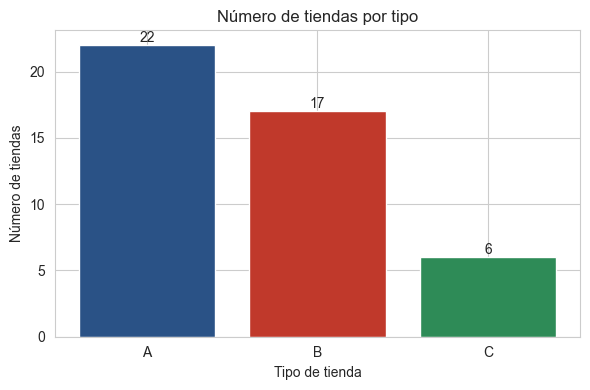

In [ ]:
conteo_tipo = df["Type"].value_counts().sort_index()
print(conteo_tipo)
print("\nPorcentaje por tipo:")
print((df["Type"].value_counts(normalize=True).sort_index() * 100).round(1))

plt.figure(figsize=(6, 4))
plt.bar(conteo_tipo.index, conteo_tipo.values, color=["#2a5286", "#c0392b", "#2e8b57"])
plt.title("Número de tiendas por tipo")
plt.xlabel("Tipo de tienda")
plt.ylabel("Número de tiendas")
for i, v in enumerate(conteo_tipo.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Distribución del tamaño de tienda

Para detectar tiendas atípicamente grandes o pequeñas antes de cruzarlo con `Type`.

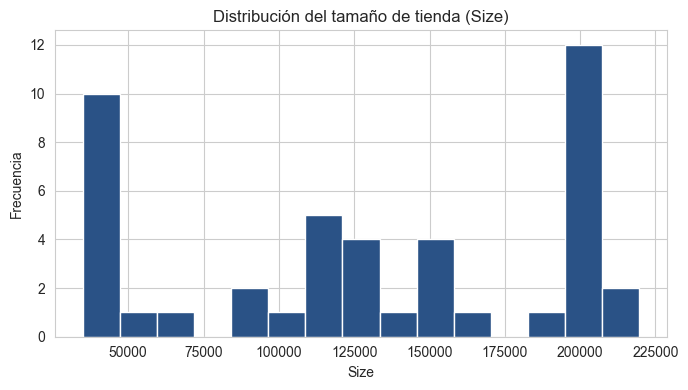

count        45.000000
mean     130287.600000
std       63825.271991
min       34875.000000
25%       70713.000000
50%      126512.000000
75%      202307.000000
max      219622.000000
Name: Size, dtype: float64


In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(df["Size"], bins=15, color="#2a5286")
plt.title("Distribución del tamaño de tienda (Size)")
plt.xlabel("Size")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(df["Size"].describe())

## Tamaño de tienda por tipo

Confirma si el tipo de tienda está asociado a su tamaño — relevante para cómo se codifique `Type` más adelante en `features.py`.

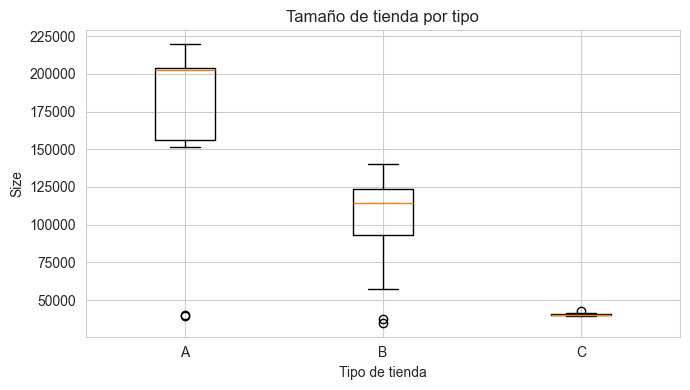

      count           mean           std      min        25%       50%  \
Type                                                                     
A      22.0  177247.727273  49392.621098  39690.0  155840.75  202406.0   
B      17.0  101190.705882  32371.137916  34875.0   93188.00  114533.0   
C       6.0   40541.666667   1304.145033  39690.0   39745.00   39910.0   

           75%       max  
Type                      
A     203819.0  219622.0  
B     123737.0  140167.0  
C      40774.0   42988.0  


In [ ]:
plt.figure(figsize=(7, 4))
orden_tipos = sorted(df["Type"].unique())
data = [df[df["Type"] == t]["Size"] for t in orden_tipos]
plt.boxplot(data, tick_labels=orden_tipos)
plt.title("Tamaño de tienda por tipo")
plt.xlabel("Tipo de tienda")
plt.ylabel("Size")
plt.tight_layout()
plt.show()

print(df.groupby("Type")["Size"].describe())

## Conclusiones

- 45 tiendas, sin nulos ni duplicados — `stores.csv` no requiere limpieza.
- 3 tipos de tienda (A, B, C), distribución desigual (A concentra casi la mitad).
- `Size` está claramente asociado a `Type` (A > B > C), por lo que ambas variables aportan información distinta y conviene conservarlas al unir con `train`/`test`.
- Pendiente para `dataset.py`: unir `stores` con `train`/`test` por `Store`; para `features.py`: codificar `Type` (dummy/one-hot).